# Статистика и введение в AB-тесты

## План занятия 

1. Recap статистики
2. Offline и online оценки
3. AB-тестирование

# 1. Recap статистики
## 1.1 Основы статистики:
- Типы данных
- Среднее
- Медиана
- Квантиль
- Дисперсия

## 1.1.1 Типы данных

Выделим три типа:

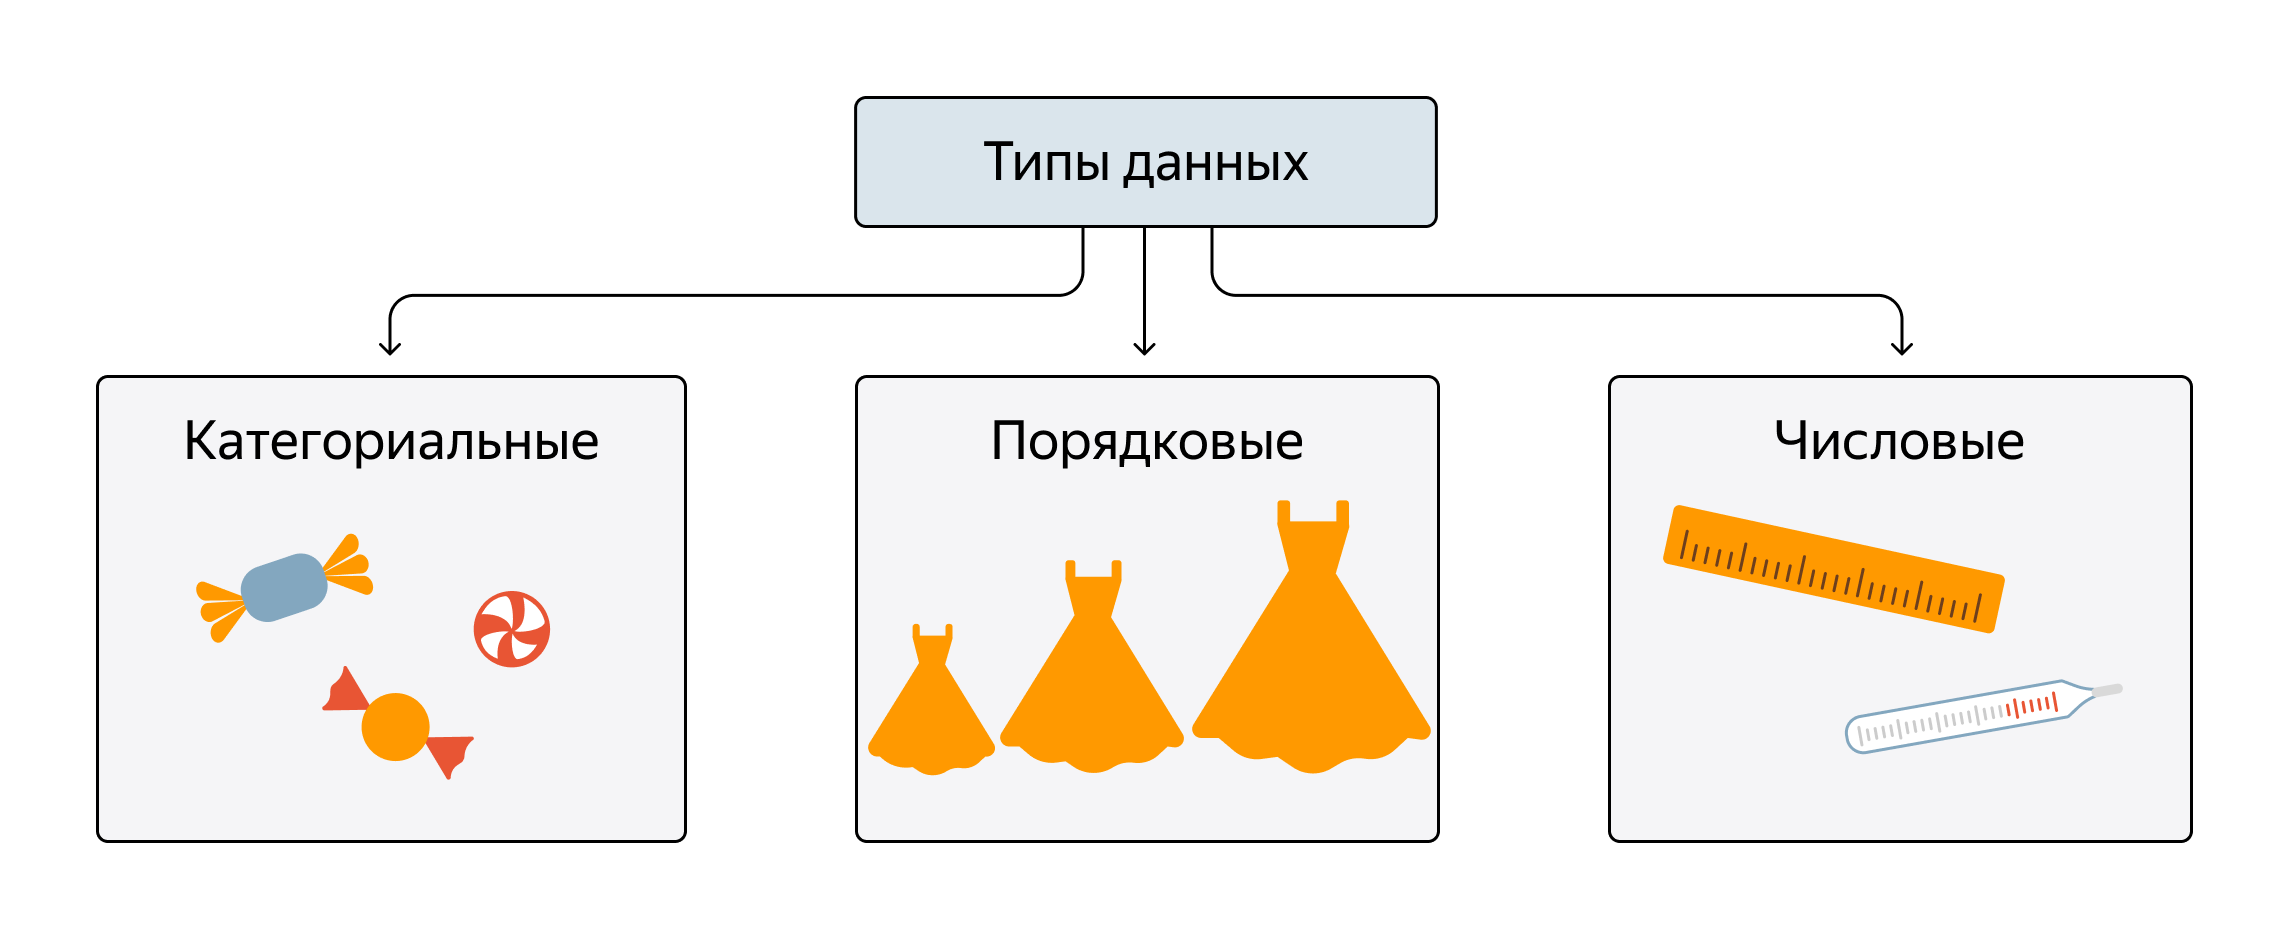

`Категориальный` тип описывает данные, которые могут принимать ограниченное количество уникальных значений. Например: 

- цвет глаз — может быть серым, голубым, зелёным или карим, это и есть категории;
- тип кондитерской продукции — конфеты, пирожные, торты;
- конфеты — бывают с арахисом, вишней, лимоном.

Давайте для начала сгенерируем данных

In [7]:
import pandas as pd

# Исходные данные
data = {
    'Цвет глаз': ['голубой', 'карий', 'зелёный', 'серый', 'голубой', 'зелёный'],
    'Тип продукции': ['конфеты', 'пирожные', 'торты', 'конфеты', 'пирожные', 'торты'],
    'Размер одежды': ['M', 'L', 'S', 'XL', 'M', 'L'],
    'Уровень образования': ['среднее', 'бакалавр', 'среднее', 'магистр', 'бакалавр', 'доктор'],
    'Число сотрудников': [15, 23, 8, 45, 12, 30],
    'Объём продаж, тыс. руб.': [150.5, 230.0, 80.3, 450.7, 120.1, 300.0],
    'Температура в цеху, °C': [22.5, 24.0, 21.0, 25.5, 23.0, 26.0],
    'Содержание сахара, %': [65, 70, 60, 75, 68, 72]
}

df = pd.DataFrame(data)
df.head()

,Цвет глаз,Тип продукции,Размер одежды,Уровень образования,Число сотрудников,"Объём продаж, тыс. руб.","Температура в цеху, °C","Содержание сахара, %"
0,голубой,конфеты,M,среднее,15,150.5,22.5,65
1,карий,пирожные,L,бакалавр,23,230.0,24.0,70
2,зелёный,торты,S,среднее,8,80.3,21.0,60
3,серый,конфеты,XL,магистр,45,450.7,25.5,75
4,голубой,пирожные,M,бакалавр,12,120.1,23.0,68


Теперь визуализируем категориальный тип данных:

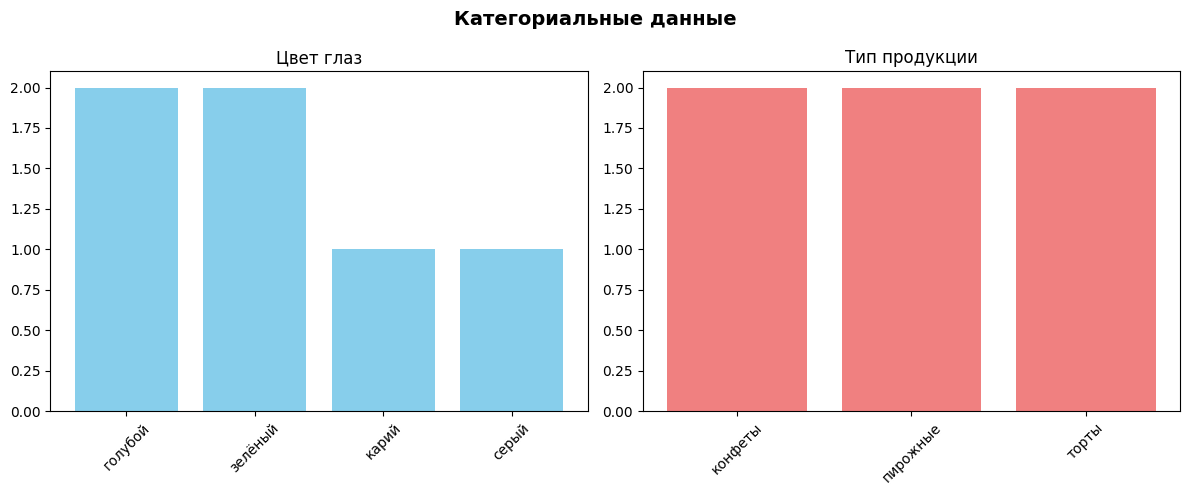

In [9]:
import matplotlib.pyplot as plt

# Категориальные признаки
cat_features = ['Цвет глаз', 'Тип продукции']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Категориальные данные", fontsize=14, fontweight='bold')

colors = ['skyblue', 'lightcoral']

for i, col in enumerate(cat_features):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

`Порядковый` тип похож на категориальный. Он тоже описывает данные, которые принимают ограниченное количество уникальных значений, но при этом для них есть естественный порядок. Например: 

- Размер одежды: XS, S, M, L, XL, XXL.
- Уровень образования: начальное, среднее, высшее.

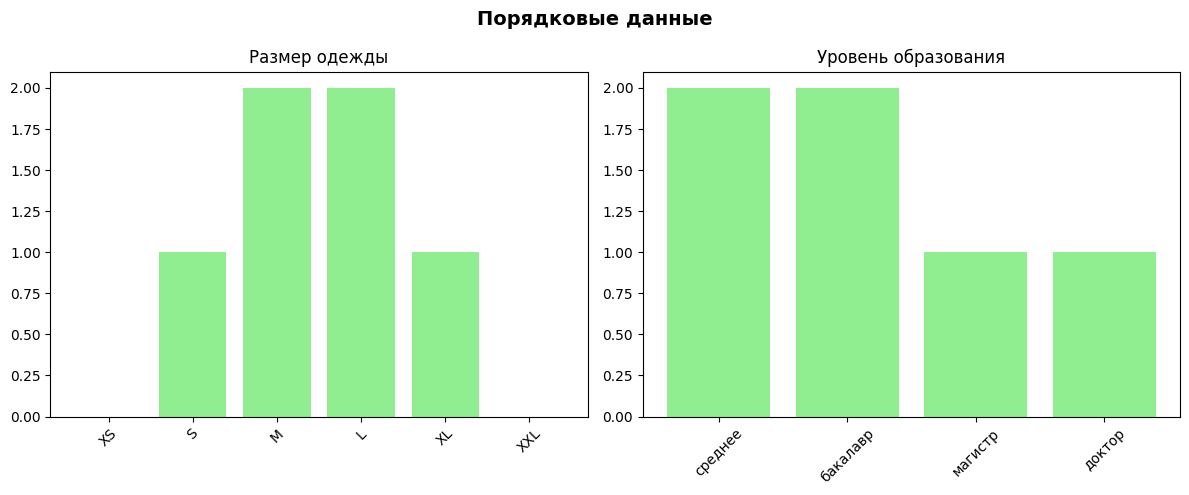

In [11]:
# Порядковые признаки — важно сохранить порядок
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL']
edu_order = ['среднее', 'бакалавр', 'магистр', 'доктор']

ord_features = ['Размер одежды', 'Уровень образования']
orders = [size_order, edu_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Порядковые данные", fontsize=14, fontweight='bold')

for i, (col, order) in enumerate(zip(ord_features, orders)):
    # Считаем частоты и упорядочиваем по логике порядка
    counts = df[col].value_counts().reindex(order, fill_value=0)
    axes[i].bar(counts.index, counts.values, color='lightgreen')
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

`Числовой` тип описывает данные, которые можно измерить. Например: 

- количество работников в компании,
- объём продаж за месяц,
- температура в цехе,
- процент сахара в ирисках.

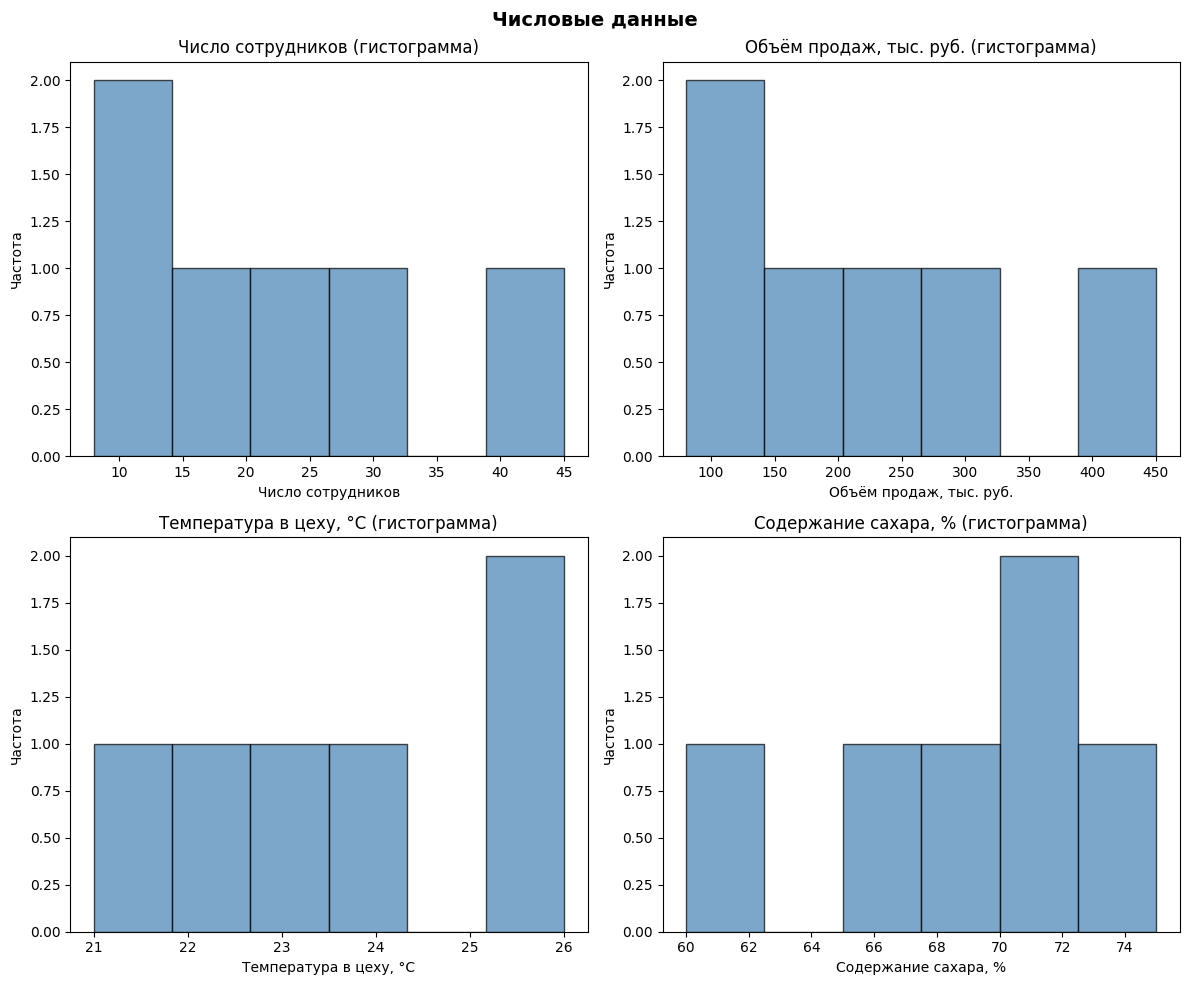

In [13]:
# Числовые признаки
num_features = ['Число сотрудников', 'Объём продаж, тыс. руб.', 'Температура в цеху, °C', 'Содержание сахара, %']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Числовые данные", fontsize=14, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=6, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} (гистограмма)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# 1.1.2 Среднее 

**Среднее арифметическое** — это мера центральной тенденции, которая показывает среднее значение всех чисел в наборе данных. Оно вычисляется как сумма всех значений, делённая на их количество.
$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$, где:

- $\bar{x}$ - среднее значение,
- $n$ - количество элементов в выборке,
- $x_i$ - i-й элемент выборки.


Среднее используется для обобщения числовой информации. Например, если вы хотите узнать, сколько в среднем продаж в день, вы складываете все значения и делите на число дней.

In [16]:
# Пример: объём продаж за 6 дней (в тыс. руб.)
sales_volume = df['Объём продаж, тыс. руб.']

# Расчёт среднего вручную
mean_sales = sum(sales_volume) / len(sales_volume)

# Округлим вывод до 2х знаков
round(mean_sales, 2)

221.93

In [17]:
# Или с помощью numpy
import numpy as np

mean_sales_np = np.mean(sales_volume)

print(f"Данные: {sales_volume}")
print(f"Средний объём продаж: {mean_sales:.2f} тыс. руб.")
print(f"Проверка через NumPy: {mean_sales_np:.2f} тыс. руб.")

Данные: 0    150.5
1    230.0
2     80.3
3    450.7
4    120.1
5    300.0
Name: Объём продаж, тыс. руб., dtype: float64
Средний объём продаж: 221.93 тыс. руб.
Проверка через NumPy: 221.93 тыс. руб.


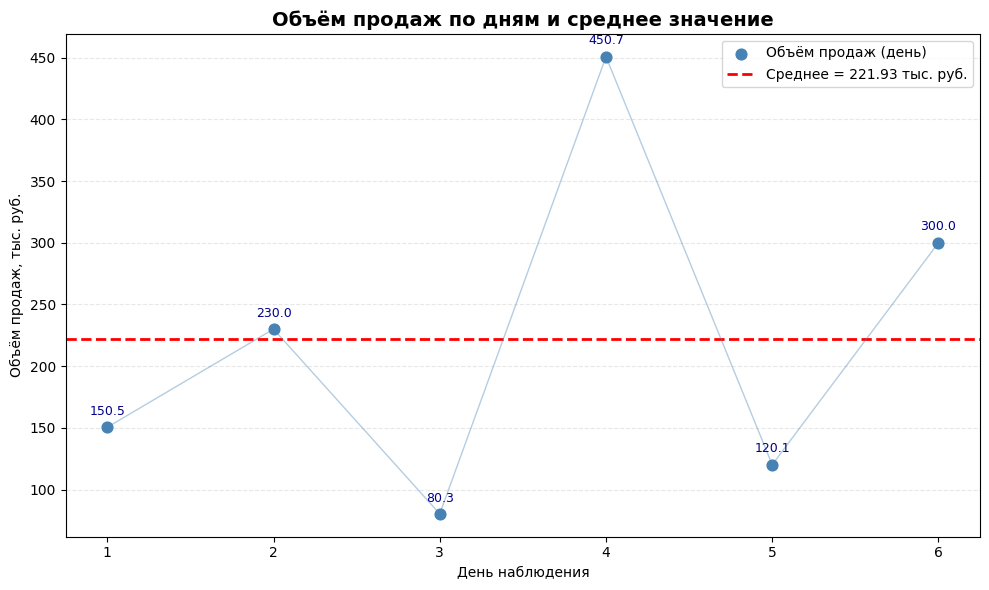

In [18]:
# Индексы для оси X (дни)
days = range(1, len(sales_volume) + 1)

# Построение графика
plt.figure(figsize=(10, 6))

# Точечная диаграмма для каждого значения
plt.scatter(days, sales_volume, color='steelblue', s=60, label='Объём продаж (день)', zorder=5)

# Горизонтальная линия — среднее значение
plt.axhline(mean_sales, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_sales:.2f} тыс. руб.')

# Соединим точки для контекста (опционально)
plt.plot(days, sales_volume, color='steelblue', alpha=0.4, linewidth=1)

# Подписи значений над точками
for i, value in enumerate(sales_volume):
    plt.text(i + 1, value + 10, f'{value:.1f}', ha='center', fontsize=9, color='darkblue')

# Оформление
plt.title("Объём продаж по дням и среднее значение", fontsize=14, fontweight='bold')
plt.xlabel("День наблюдения")
plt.ylabel("Объём продаж, тыс. руб.")
plt.xticks(days)  # 1, 2, 3...
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

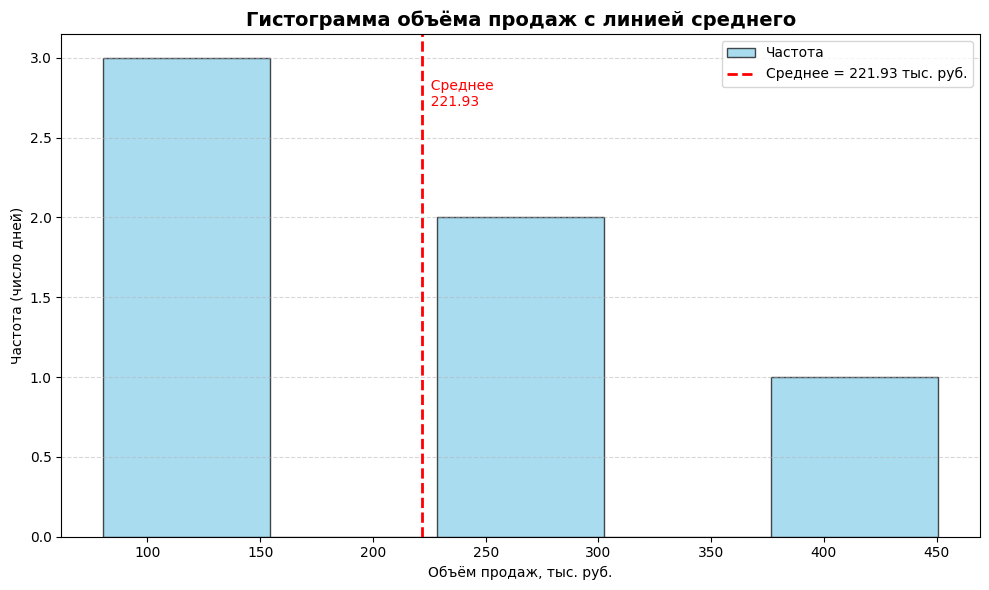

In [19]:
# Построение гистограммы
plt.figure(figsize=(10, 6))
n_bins = 5  # можно изменить на 4 или 6 в зависимости от желаемой детализации
n, bins, patches = plt.hist(sales_volume, bins=n_bins, color='skyblue', 
                            edgecolor='black', alpha=0.7, label='Частота')

# Линия среднего
plt.axvline(mean_sales, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее = {mean_sales:.2f} тыс. руб.')

# Подпись над линией среднего
plt.text(mean_sales, max(n) * 0.9, f'  Среднее\n  {mean_sales:.2f}', 
         color='red', fontsize=10, ha='left')

# Оформление
plt.title("Гистограмма объёма продаж с линией среднего", fontsize=14, fontweight='bold')
plt.xlabel("Объём продаж, тыс. руб.")
plt.ylabel("Частота (число дней)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Важно** понимать, что среднее чувствительно к выбросам (экстремально большим или маленьким значениям).

## 1.1.3 Медиана

**Медиана** — это значение, которое делит упорядоченную выборку числовых данных на две равные части:

- половина значений меньше или равна медиане,
- половина — больше или равна.

Она является мерой центральной тенденции, как и среднее, но менее чувствительна к выбросам (экстремальным значениям).


$$\text{Med}(x) = 
\begin{cases}
x_{(n+1)/2}, & \text{если } n \text{ нечётное} \\
\frac{1}{2}(x_{n/2} + x_{n/2 + 1}), & \text{если } n \text{ чётное}
\end{cases}$$, где:

- $x$ — упорядоченный (отсортированный) массив данных,
- $n$ — количество элементов.

- Если число элементов нечётное — медиана — это **средний** элемент после сортировки.
- Если чётное — медиана — среднее арифметическое двух центральных элементов.

Пример:

- Данные: [10, 20, 30] → медиана = 20
- Данные: [10, 20, 30, 40] → медиана = (20 + 30)/2 = 25

В отличие от среднего, медиана не "перекашивается" из-за одного очень большого значения (например, 1000). Поэтому её часто используют в реальных задачах: зарплаты, доходы, время доставки и т.д. 

In [23]:
# Сортируем данные
sorted_sales = sorted(sales_volume)
n = len(sorted_sales)

# Расчёт медианы вручную
if n % 2 == 1:
    # Нечётное количество
    median_idx = [n // 2]
    median_sales = sorted_sales[median_idx[0]]
else:
    # Чётное количество
    left_idx = n // 2 - 1
    right_idx = n // 2
    median_idx = [left_idx, right_idx]
    median_sales = (sorted_sales[left_idx] + sorted_sales[right_idx]) / 2

# Округляем до 2х знаков
median_sales_rounded = round(median_sales, 2)
median_sales_rounded

190.25

In [24]:
# Через statistics (проще!)
import statistics
median_stats = round(statistics.median(sales_volume), 2)

print(f"Данные (до сортировки): {sales_volume}")
print(f"Данные (после сортировки): {sorted_sales}")
print(f"Медиана (вручную): {median_sales_rounded} тыс. руб.")
print(f"Медиана (через statistics): {median_stats} тыс. руб.")

Данные (до сортировки): 0    150.5
1    230.0
2     80.3
3    450.7
4    120.1
5    300.0
Name: Объём продаж, тыс. руб., dtype: float64
Данные (после сортировки): [80.3, 120.1, 150.5, 230.0, 300.0, 450.7]
Медиана (вручную): 190.25 тыс. руб.
Медиана (через statistics): 190.25 тыс. руб.


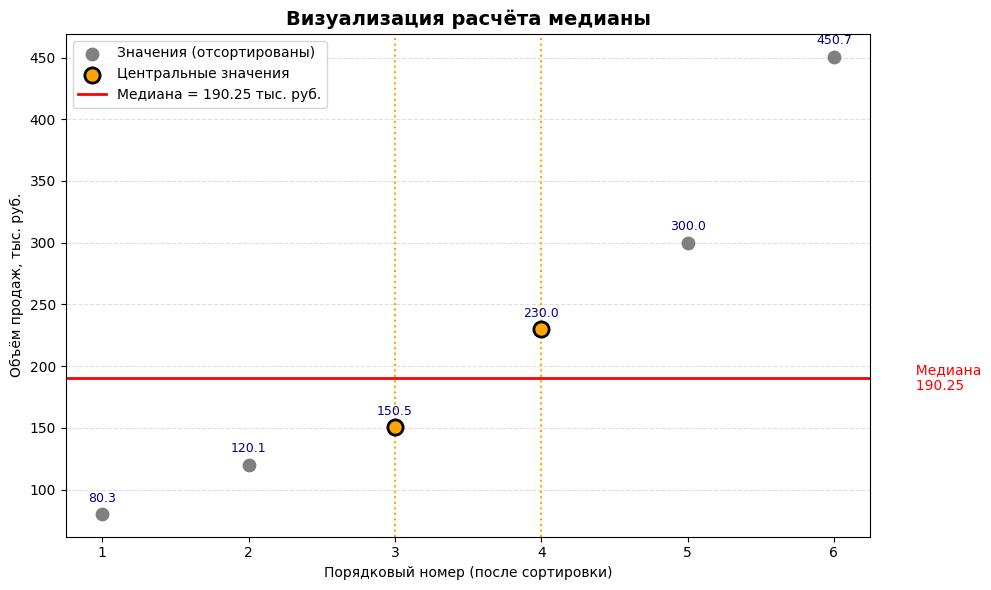

In [25]:
# Позиции на оси X — индексы элементов (1, 2, 3...)
positions = list(range(1, n + 1))

# Построение графика
plt.figure(figsize=(10, 6))

# Все точки (отсортированные значения)
plt.scatter(positions, sorted_sales, color='gray', s=80, label='Значения (отсортированы)', zorder=5)

# Выделяем центральные точки (для медианы)
plt.scatter([pos + 1 for pos in median_idx], [sorted_sales[i] for i in median_idx],
            color='orange', s=120, edgecolor='black', linewidth=2, label='Центральные значения', zorder=6)

# Линия медианы (горизонтальная)
plt.axhline(median_sales, color='red', linestyle='-', linewidth=2, label=f'Медиана = {median_sales:.2f} тыс. руб.')

# Вертикальные пунктирные линии к центральным точкам (опционально)
for idx in median_idx:
    plt.axvline(idx + 1, color='orange', linestyle=':', linewidth=1.5)

# Подписи значений над точками
for i, value in enumerate(sorted_sales):
    plt.text(i + 1, value + 10, f'{value:.1f}', ha='center', fontsize=9, color='darkblue')

# Подпись медианы
plt.text(n + 0.5, median_sales, f'  Медиана\n  {median_sales:.2f}', 
         color='red', fontsize=10, va='center')

# Оформление
plt.title("Визуализация расчёта медианы", fontsize=14, fontweight='bold')
plt.xlabel("Порядковый номер (после сортировки)")
plt.ylabel("Объём продаж, тыс. руб.")
plt.xticks(positions, [f'{i}' for i in positions])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

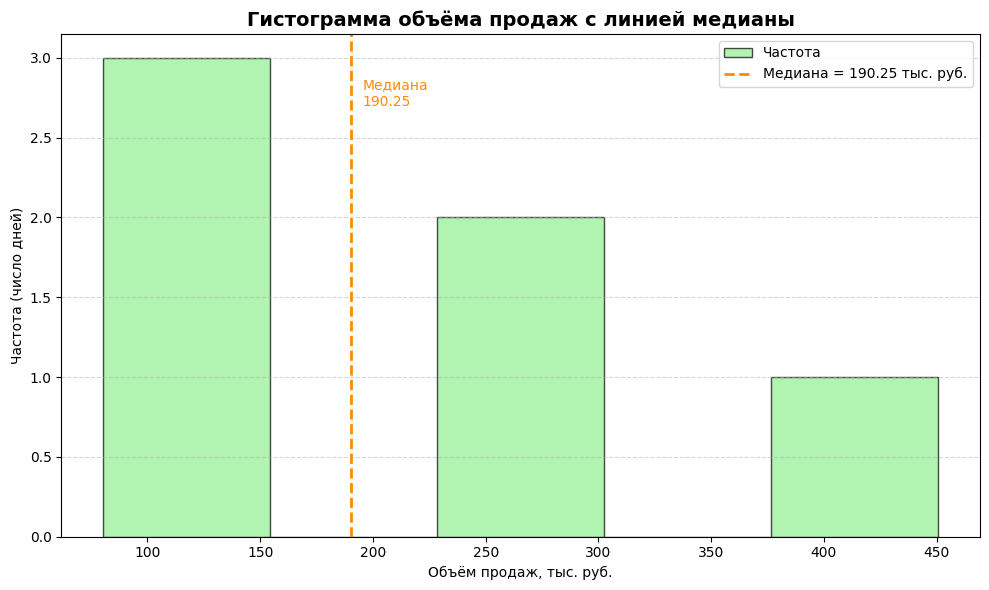

In [26]:
# Построение гистограммы
plt.figure(figsize=(10, 6))
n_bins = 5
n, bins, patches = plt.hist(sales_volume, bins=n_bins, color='lightgreen', 
                            edgecolor='black', alpha=0.7, label='Частота')

# Вертикальная линия — медиана
plt.axvline(median_sales, color='darkorange', linestyle='--', linewidth=2, 
            label=f'Медиана = {median_sales:.2f} тыс. руб.')

# Подпись рядом с линией
plt.text(median_sales + 5, max(n) * 0.9, f'Медиана\n{median_sales:.2f}', 
         color='darkorange', fontsize=10, ha='left')

# Оформление
plt.title("Гистограмма объёма продаж с линией медианы", fontsize=14, fontweight='bold')
plt.xlabel("Объём продаж, тыс. руб.")
plt.ylabel("Частота (число дней)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Почему медиана важна?

Сравним со средним:

- Среднее: ~221.93 (выше из-за выброса 450.7)
- Медиана: ~190.25 (лучше отражает "типичный" день)

Медиана даёт более устойчивую оценку центра, особенно если данные "скошены".

## 1.1.4 Квантиль

**Квантиль** — это значение, ниже которого находится определённая доля данных из выборки.
Он делит упорядоченные данные на две части: одна содержит заданную долю значений, другая — оставшуюся.

Например:

- Медиана — это квантиль уровня 0.5: 50% значений меньше или равны ему.
- Квантиль уровня 0.25 (первый квартиль) — 25% данных меньше него.

$Q(p)$ — это такое значение, что $p \cdot 100\%$ данных $\leq Q(p)$, где $0 < p < 1$.

**Квантиль уровня p** — это значение, которое отделяет нижние p·100% данных от остальных.

Частные случаи:

- $p=0.25$ → первый квартиль (Q1)
- $p=0.50$ → медиана (Q2)
- $p=0.75$ → третий квартиль (Q3)

Пример:

Если квантиль 0.8 для зарплат равен 120 тыс. руб., значит:

80% людей получают не больше 120 тыс. руб. 

In [30]:
# Расчёт квантилей с помощью numpy.quantile()
q_025 = np.quantile(sales_volume, 0.25)   # 25%
q_050 = np.quantile(sales_volume, 0.50)   # 50% (медиана)
q_075 = np.quantile(sales_volume, 0.75)   # 75%
q_090 = np.quantile(sales_volume, 0.90)   # 90%

print(f"Данные: {sorted(sales_volume)}")
print(f"Квантиль 0.25 (Q1): {q_025:.2f}")
print(f"Квантиль 0.50 (медиана): {q_050:.2f}")
print(f"Квантиль 0.75 (Q3): {q_075:.2f}")
print(f"Квантиль 0.90: {q_090:.2f}")

Данные: [80.3, 120.1, 150.5, 230.0, 300.0, 450.7]
Квантиль 0.25 (Q1): 127.70
Квантиль 0.50 (медиана): 190.25
Квантиль 0.75 (Q3): 282.50
Квантиль 0.90: 375.35


**Как вычисляется?**

Поскольку между элементами может не быть точного значения, numpy (и другие библиотеки) используют интерполяцию — находят значение "между строк", пропорционально расстоянию.

Например, квантиль 0.25 между 120.1 и 150.5 → получается 135.30.


**Зачем нужны квантили?**

- Оценивать распределение данных (например, какая зарплата у 90% сотрудников).
- Находить выбросы через IQR (межквартильный размах): $IQR=Q(0.75)−Q(0.25)$
- Строить ящики с усами (boxplot).
- Анализировать время отклика, доходы, продажи — везде, где есть перекос.

In [32]:
# Вычисляем квартили и IQR
Q1 = np.quantile(sales_volume, 0.25)
Q3 = np.quantile(sales_volume, 0.75)
IQR = Q3 - Q1

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Находим выбросы
outliers = sales_volume[(sales_volume < lower_bound) | (sales_volume > upper_bound)]

print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR = Q3 - Q1 = {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Выбросы: {list(outliers)}")

Q1 (25%): 127.70
Q3 (75%): 282.50
IQR = Q3 - Q1 = 154.80
Нижняя граница: -104.50
Верхняя граница: 514.70
Выбросы: []


C:\Users\NeKonn\AppData\Local\Temp\ipykernel_2596\4124736617.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(sales_volume, patch_artist=True,


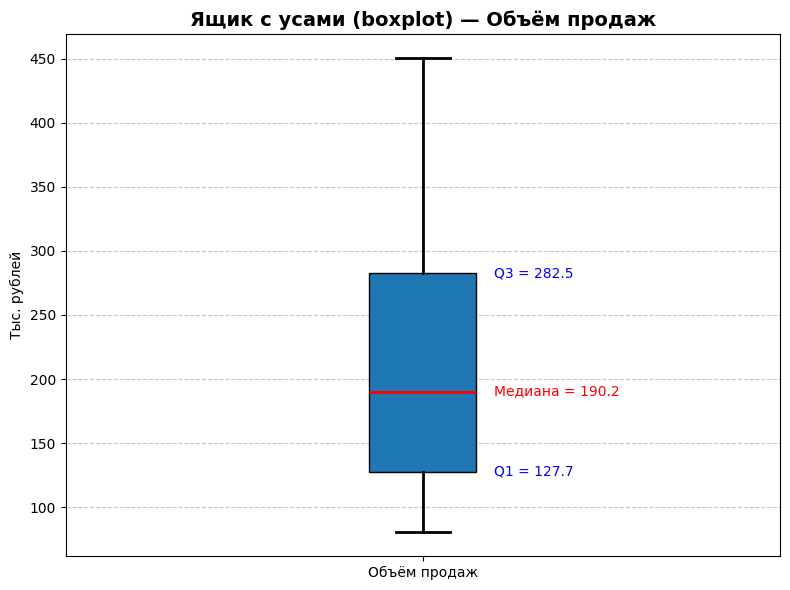

In [33]:
# Построение boxplot
plt.figure(figsize=(8, 6))
box = plt.boxplot(sales_volume, patch_artist=True, 
                  labels=['Объём продаж'],
                  whiskerprops=dict(linewidth=2),
                  capprops=dict(linewidth=2),
                  medianprops=dict(color='red', linewidth=2))

# Оформление
plt.title("Ящик с усами (boxplot) — Объём продаж", fontsize=14, fontweight='bold')
plt.ylabel("Тыс. рублей")

# Подписи на графике
plt.text(1.1, Q3, f'Q3 = {Q3:.1f}', va='center', color='blue', fontsize=10)
plt.text(1.1, Q1, f'Q1 = {Q1:.1f}', va='center', color='blue', fontsize=10)
plt.text(1.1, np.median(sales_volume), f'Медиана = {np.median(sales_volume):.1f}', 
         va='center', color='red', fontsize=10)

if len(outliers) > 0:
    plt.text(1.1, max(outliers), f'Выброс: {max(outliers):.1f}', 
             va='center', color='orange', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 1.1.5 Дисперсия

**Дисперсия (variance)** — это средний квадрат отклонения значений от их среднего арифметического.
Она показывает, насколько сильно значения в данных "разбросаны" вокруг среднего.
- 

Чем больше дисперсия — тем сильнее данные рассеян- ы.
Чем ближе к нулю — тем все значения ближе к средн

$$\text{Var}(x) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$, где:

- $x_i$ - i-е значение,
- $\bar{x}$ - среднее арифметическое,
- $n$ - количество элементов.

Дисперсия измеряется в квадратах единиц: если продажи в тыс. руб., то дисперсия — в тыс. руб.².

Из-за этого её сложно интерпретировать напрямую — поэтому часто используют стандартное отклонение (корень из дисперсии).

Но дисперсия важна в статистике и ML: используется в регрессии, ANOVA, нормализации и т.д.

In [36]:
import numpy as np


# Среднее
mean_sales = np.mean(sales_volume)

# Расчёт дисперсии вручную
variance_manual = np.mean((sales_volume - mean_sales) ** 2)

# Через numpy
variance_np = np.var(sales_volume)  # ddof=0 — дисперсия генеральной совокупности
variance_sample = np.var(sales_volume, ddof=1)  # ddof=1 — исправленная выборочная дисперсия

print(f"Данные: {list(sales_volume)}")
print(f"Среднее: {mean_sales:.2f}")
print(f"Дисперсия (вручную): {variance_manual:.2f}")
print(f"Дисперсия (numpy, ddof=0): {variance_np:.2f}")
print(f"Выборочная дисперсия (ddof=1): {variance_sample:.2f}")

Данные: [150.5, 230.0, 80.3, 450.7, 120.1, 300.0]
Среднее: 221.93
Дисперсия (вручную): 15671.07
Дисперсия (numpy, ddof=0): 15671.07
Выборочная дисперсия (ddof=1): 18805.28


In [37]:
# Отклонение
deviations = sales_volume - mean_sales
squared_deviations = deviations ** 2

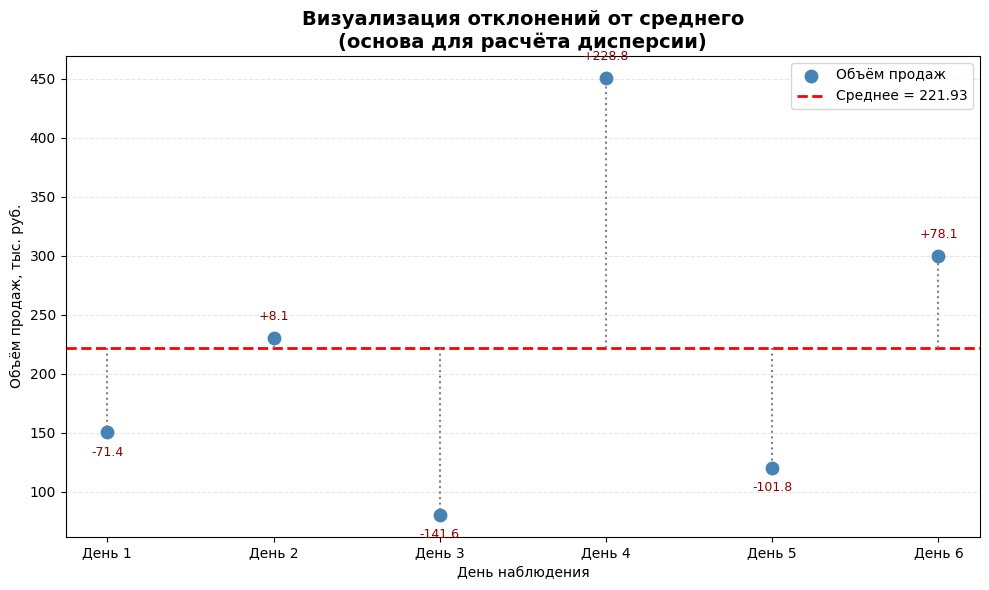

In [38]:
# Позиции для оси X (дни)
days = range(1, len(sales_volume) + 1)

# Построение графика
plt.figure(figsize=(10, 6))

# Точки данных
plt.scatter(days, sales_volume, color='steelblue', s=80, label='Объём продаж', zorder=5)

# Линия среднего
plt.axhline(mean_sales, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_sales:.2f}')

# Вертикальные линии — отклонения от среднего
for i in range(len(days)):
    plt.vlines(days[i], mean_sales, sales_volume.iloc[i], 
               colors='gray', linestyles='dotted', linewidth=1.5)

# Подписи отклонений (сверху или снизу)
for i, dev in enumerate(deviations):
    offset = 15 if dev > 0 else -20
    plt.text(days[i], sales_volume.iloc[i] + offset, f'{dev:+.1f}', 
             ha='center', fontsize=9, color='darkred')

# Оформление
plt.title("Визуализация отклонений от среднего\n(основа для расчёта дисперсии)", fontsize=14, fontweight='bold')
plt.xlabel("День наблюдения")
plt.ylabel("Объём продаж, тыс. руб.")
plt.xticks(days, [f'День {i}' for i in days])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

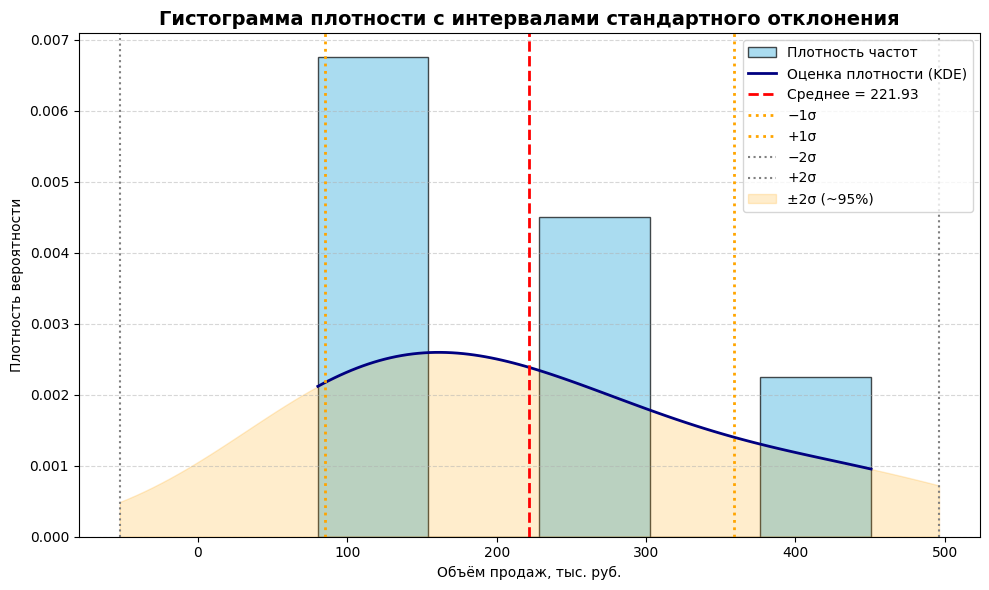

In [39]:
# Среднее и стандартное отклонение
mean_sales = np.mean(sales_volume)
std_sales = np.std(sales_volume, ddof=1)  # исправленное (выборочное) отклонение

# Построение гистограммы плотности
plt.figure(figsize=(10, 6))
plt.hist(sales_volume, bins=5, color='skyblue', edgecolor='black', alpha=0.7,
         density=True, label='Плотность частот')

# Линия ядерной оценки плотности (KDE) — опционально
from scipy.stats import gaussian_kde
kde = gaussian_kde(sales_volume)
x_range = np.linspace(min(sales_volume), max(sales_volume), 100)
plt.plot(x_range, kde(x_range), color='navy', linewidth=2, label='Оценка плотности (KDE)')

# Линия среднего
plt.axvline(mean_sales, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_sales:.2f}')

# Интервалы ±1σ, ±2σ
plt.axvline(mean_sales - std_sales, color='orange', linestyle=':', linewidth=2, label=f'−1σ')
plt.axvline(mean_sales + std_sales, color='orange', linestyle=':', linewidth=2, label=f'+1σ')
plt.axvline(mean_sales - 2*std_sales, color='gray', linestyle=':', linewidth=1.5, label=f'−2σ')
plt.axvline(mean_sales + 2*std_sales, color='gray', linestyle=':', linewidth=1.5, label=f'+2σ')

# Закрашенные области (доверительные интервалы ~95% при нормальности)
x_fill_2s = np.linspace(mean_sales - 2*std_sales, mean_sales + 2*std_sales, 100)
y_fill_2s = kde(x_fill_2s)
plt.fill_between(x_fill_2s, y_fill_2s, color='orange', alpha=0.2, label='±2σ (~95%)')

# Оформление
plt.title("Гистограмма плотности с интервалами стандартного отклонения", fontsize=14, fontweight='bold')
plt.xlabel("Объём продаж, тыс. руб.")
plt.ylabel("Плотность вероятности")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Зачем нужна дисперсия?

- Чтобы оценить стабильность процесса: маленькая дисперсия → продажи стабильны; большая → есть резкие скачки.
- Как шаг к расчёту стандартного отклонения: $σ= \sqrt{Var} $
- В формулах машинного обучения (например, R², PCA, регрессия).

## 1.2 Статистические тесты:
- Стандартная ошибка среднего
- Статистические гипотезы
- p-value
- T-тест и распределение Стьюдента
- Сравнение групп

### 1.2.1 Стандартная ошибка среднего
**Распределение выборочных средних** — это распределение, показывающее, какие значения принимает среднее значение случайной выборки из генеральной совокупности при многократном повторении эксперимента.

**Стандартная ошибка среднего (Standard Error, SE)** — это стандартное отклонение выборочных средних, которое зависит от количества наблюдений в выборке и стандартного отклонения генеральной совокупности.
$$SE = \frac{\sigma}{\sqrt{n}}.$$, где

- $σ$ — стандартное отклонение выборки,
- $n$ — объём выборки (число наблюдений).

Часто вместо $σ$ используется исправленное выборочное стандартное отклонение с $ddof=1$

Стандартная ошибка среднего (SE) указывает, насколько большая ожидается погрешность при измерении среднего значения по выборке. Чем больше дисперсия в самих данных и чем меньше выборка, тем больше погрешность.

- Стандартное отклонение $σ$ — показывает, как разбросаны данные.
- Стандартная ошибка среднего (SE) — показывает, как разбросано среднее, если бы мы много раз брали выборки.

Пример:

У вас 6 дней продаж. Вы посчитали среднее.
SE говорит: _Если бы вы собирали такие же группы по 6 дней снова и снова — насколько бы различались эти средние?_

- Маленький SE = среднее стабильно.
- Большой SE = среднее может "скакать" от выборки к выборке.

In [43]:
import numpy as np

# Данные
n = len(sales_volume)

# Стандартное отклонение (исправленное, ddof=1)
std_dev = np.std(sales_volume, ddof=1)

# Стандартная ошибка среднего
se_mean = std_dev / np.sqrt(n)

print(f"Данные: {list(sales_volume)}")
print(f"Среднее: {np.mean(sales_volume):.2f} тыс. руб.")
print(f"Стандартное отклонение (σ): {std_dev:.2f}")
print(f"Стандартная ошибка среднего (SE): {se_mean:.2f}")

Данные: [150.5, 230.0, 80.3, 450.7, 120.1, 300.0]
Среднее: 221.93 тыс. руб.
Стандартное отклонение (σ): 137.13
Стандартная ошибка среднего (SE): 55.98


SE ≈ 57.18 означает, что если бы мы много раз брали выборки по 6 дней, то средние колебались бы вокруг истинного значения с средним отклонением около ±57 тыс. руб.

Это довольно большой SE относительно среднего → значит, оценка среднего не очень точная из-за малого объёма выборки и высокой дисперсии.

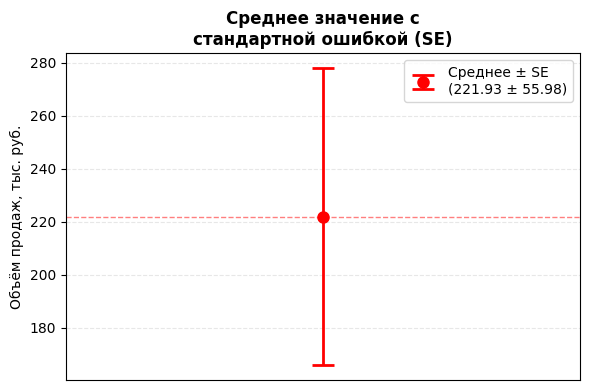

In [45]:
mean_sales = np.mean(sales_volume)

plt.figure(figsize=(6, 4))

# Точечная диаграмма с ошибкой
plt.errorbar(1, mean_sales, yerr=se_mean, fmt='o', color='red',
             capsize=8, capthick=2, markersize=8, linewidth=2,
             label=f'Среднее ± SE\n({mean_sales:.2f} ± {se_mean:.2f})')

# Горизонтальные линии для наглядности
plt.axhline(mean_sales, color='red', alpha=0.5, linestyle='--', linewidth=1)

# Оформление
plt.title("Среднее значение с\nстандартной ошибкой (SE)", fontsize=12, fontweight='bold')
plt.ylabel("Объём продаж, тыс. руб.")
plt.xlim(0.5, 1.5)
plt.xticks([])  # убираем ось X
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Где применяется SE?
- При построении доверительных интервалов:
$CI= \bar{x}±t⋅SE$
- В A/B-тестировании — чтобы оценить значимость различий.
- В научных статьях — почти всегда указывают среднее ± SE.

### 1.2.2 Статистические гипотезы

Статистическая гипотеза — это утверждение о параметрах или распределении генеральной совокупности, которое можно проверить с помощью выборочных данных.

Например:

- "Средний объём продаж изменился после запуска рекламы"
- "Новый сайт работает быстрее старого"
- "Цвет упаковки влияет на продажи"
  
Мы не можем быть уверены на 100%, но можем оценить вероятность того, что наблюдаемое различие — случайно.

**Основные понятия**

1. Нулевая гипотеза $H_0$
Утверждение о "статус-кво", отсутствии эффекта или различия.

Пример:

$H_0$: Средний объём продаж до и после рекламы одинаков. 

2. Альтернативная гипотеза $H_1$ или $H_a$
3. 
Утверждение, которое мы хотим доказать — наличие эффекта или различия.

Пример:

$H_1$: Средний объём продаж после рекламы стал выше. 

**Как работает проверка гипотез?**

1. Формулируем $H_0$ и $H_1$
2. Выбираем тест (t-тест, z-тест, Манна-Уитни и др.)
3. Считаем p-value
4. Если p-value < уровня значимости (обычно $α=0.05$) → отвергаем $H_0$
 
**Важно** мы никогда не "принимаем" нулевую гипотезу — мы либо отвергаем, либо не отвергаем. 

**Пример**

Предположим, вы знаете, что средний объём продаж в отрасли — 200 тыс. руб. в день.
Хотим проверить: отличается ли наш магазин?

In [49]:
from scipy.stats import ttest_1samp
import numpy as np

# Наши данные
sales_volume = df['Объём продаж, тыс. руб.']
mu_0 = 200  # среднее в отрасли

# Одновыборочный t-тест
t_stat, p_value = ttest_1samp(sales_volume, popmean=mu_0)

print(f"Среднее по выборке: {np.mean(sales_volume):.2f}")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"→ p-value < {alpha}: отвергаем H₀ — есть значимое отличие")
else:
    print(f"→ p-value ≥ {alpha}: не отвергаем H₀ — нет оснований говорить об отличии")

Среднее по выборке: 221.93
t-статистика: 0.392
p-value: 0.7114
→ p-value ≥ 0.05: не отвергаем H₀ — нет оснований говорить об отличии


Хотя среднее у нас выше (221.93 > 200), из-за малого размера выборки (n=6) и большого разброса, различие не является статистически значимым.

Интерпретация p-value

- p-value = 0.7163 — это вероятность получить такие или более экстремальные данные, если H₀ верна.
- Чем меньше p-value — тем сильнее свидетельства против $H_0$.
- Обычный порог: α=0.05 (5%).

### Типы ошибок

| Решение →<br>Реальность ↓ | Отклоняем $H_0$ | Не отклоняем $H_0$ |
|--------------------------|------------------|--------------------|
| $H_0$ верна              | Ошибка I рода ($\alpha$) | Правильно |
| $H_0$ неверна            | Правильно        | Ошибка II рода ($\beta$) |

- Ошибка I рода: "ложная тревога" — сказали, что есть эффект, а его нет.
- Ошибка II рода: "пропустили сигнал" — не заметили реальный эффект.

### Распространённые статистические тесты

| Тест | Когда использовать |
|------|---------------------|
| **t-тест для одной выборки** | Сравнение среднего значения одной группы с заданным числом (например, 200 тыс. руб.) |
| **t-тест для двух независимых выборок** | Проверка разницы между средними двух групп (например, старый vs новый сайт) |
| **ANOVA** | Сравнение средних более чем двух групп (например, три разных рекламных кампании) |
| **Критерий Манна-Уитни U** | Непараметрический тест для сравнения двух групп, когда данные не нормальны |
| **χ²-тест (хи-квадрат)** | Проверка связи между двумя категориальными переменными (например, цвет упаковки и факт покупки) |

**Зачем это нужно?**

- Принимать решения на основе данных, а не интуиции.
- Оценивать эффективность изменений (реклама, UX, цены).
- Подтверждать или опровергать бизнес-гипотезы.

### 1.2.3 p-value

p-value (p-значение) — это вероятность получить такие или ещё более экстремальные данные в предположении, что нулевая гипотеза $H_0$ верна.

Другими словами:

Если на самом деле нет никакого эффекта, какова вероятность увидеть результат, который мы получили (или ещё более сильный)? 

$p\text{-value} = P(\text{данные} \geq \text{наблюдаемых} \mid H_0)$

Где:

- $H_0$ — нулевая гипотеза,
- условная вероятность считается при условии, что $H_0$ истинна.

Представьте:

- Вы запустили рекламу.
- До неё средние продажи — 200 тыс. руб.
- После — 250 тыс. руб.
- 
Вопрос: это потому что реклама помогла, или просто случайно повезло?

p-value ответит:

«Если реклама НЕ влияет $H_0$, то какова вероятность получить рост до 250 или больше — чисто случайно?»

- Если p-value = 0.01 → только 1% шансов, что такое могло произойти случайно → скорее всего, реклама работает.
- Если p-value = 0.30 → 30% шансов — вполне могло быть случайностью → нет оснований говорить об эффекте.

### Как интерпретировать p-value?

| p-value        | Интерпретация |
|----------------|---------------|
| $p < 0.01$     | Очень сильные доказательства против $H_0$ |
| $p < 0.05$     | Сильные доказательства против $H_0$ — результат считается **статистически значимым** |
| $p \geq 0.05$  | Недостаточно доказательств против $H_0$ — **не отвергаем нулевую гипотезу** |

**Важно** "не отвергаем $H_0$" — это не то же самое, что "принимаем $H_0$".

- p-value — это НЕ вероятность того, что $H_0$ верна.
- Это НЕ вероятность ошибки.
- Это НЕ мера силы эффекта. 


###  Распространённые заблуждения

| Заблуждение | Правильное понимание |
|------------|------------------------|
| *"p = 0.04 — значит, с вероятностью 96% альтернативная гипотеза верна"* | Неверно. p-value **не измеряет вероятность истинности гипотез**. |
| *"Чем меньше p-value, тем сильнее эффект"* | Не обязательно. Малый p может быть из-за большого размера выборки, даже если эффект слабый. |
| *"p > 0.05 — значит, нет никакого эффекта"* | Нет. Это означает лишь, что **недостаточно данных**, чтобы его обнаружить. |
| *"p-value — это вероятность того, что H₀ верна"* | Нет. p-value — это вероятность **данных при условии**, что $H_0$ верна. |
| *"Если тест значим, результат всегда важен"* | Не так. Статистическая значимость ≠ практическая важность (эффект может быть крошечным). |

**Как используется в проверке гипотез?**

- Задаём уровень значимости α (обычно 0.05).
- Считаем p-value.
- Принимаем решение

**Зачем это нужно?**

- Принимать решения на основе данных, а не интуиции.
- Оценивать эффективность изменений: UX, рекламы, цен.
- Избегать ложных выводов ("кажется, лучше стало", но на самом деле — шум).

### 1.2.4 T-тест и распределение Стьюдента

**t-тест** — это статистический тест, который проверяет, отличается ли среднее значение одной или двух групп от некоторого значения или друг от друга, когда дисперсия неизвестна, а выборка — небольшого размера.

Он основан на распределении Стьюдента (t-распределении).

### Основные типы t-тестов

| Тип t-теста | Когда используется | Пример |
|-------------|---------------------|--------|
| **Одновыборочный t-тест** | Сравнение среднего одной группы с заданным значением | Проверка, отличается ли средний объём продаж от 200 тыс. руб. |
| **Двухвыборочный t-тест (независимый)** | Сравнение средних двух независимых групп | Сравнение продаж в двух разных магазинах |
| **Парный t-тест (зависимый)** | Сравнение средних в одной группе до и после воздействия | Объём продаж до и после рекламной кампании в одном и том же магазине |

**Распределение Стьюдента (t-распределение)**

Когда мы не знаем истинное стандартное отклонение генеральной совокупности (что почти всегда), мы используем его оценку по выборке. Из-за этого неопределённость возрастает — особенно при малом объёме данных.

Распределение Стьюдента учитывает эту неопределённость:

- Похоже на нормальное распределение, но с более тяжёлыми хвостами.
- Чем меньше степеней свободы (обычно n−1 ), тем шире хвосты → больше "осторожность" при выводах.
- При увеличении объёма выборки (n→∞ ) t-распределение стремится к нормальному.

**t-статистика для одновыборочного теста**

$$
t = \frac{\bar{x} - \mu_0}{SE} = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$$

Где:
- $\bar{x}$ — выборочное среднее,
- $\mu_0$ — предполагаемое значение (по $H_0$),
- $s$ — выборочное стандартное отклонение,
- $n$ — размер выборки,
- $SE$ — стандартная ошибка среднего.

Пример: одновыборочный t-тест

Проверим, отличается ли средний объём продаж нашей кондитерской от отраслевого стандарта в 200 тыс. руб.

In [55]:
from scipy.stats import ttest_1samp

# t-тест
t_stat, p_value = ttest_1samp(sales_volume, popmean=200)

print(f"Среднее: {np.mean(sales_volume):.2f}")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

Среднее: 221.93
t-статистика: 0.392
p-value: 0.7114


Несмотря на то, что среднее выше, из-за малой выборки (n=6) и большого разброса, различие не является статистически значимым.

**Почему именно t-распределение?**
- При малой выборке оценка дисперсии $s^2$ сама по себе случайна.
- t-распределение «расширяет» доверительные интервалы и делает тест более консервативным.
- Это снижает риск ошибки I рода (ложноположительный результат).

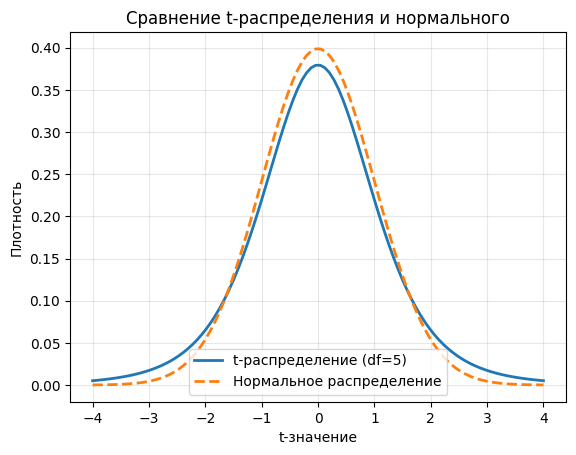

In [57]:
from scipy.stats import t, norm

x = np.linspace(-4, 4, 100)

# Плотности: t-распределение с df=5 и стандартное нормальное
plt.plot(x, t.pdf(x, df=5), label='t-распределение (df=5)', linewidth=2)
plt.plot(x, norm.pdf(x), label='Нормальное распределение', linestyle='--', linewidth=2)

plt.title("Сравнение t-распределения и нормального")
plt.xlabel("t-значение")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Видно, что у t-распределения более тяжёлые хвосты — значит, экстремальные значения встречаются чаще, чем в нормальном распределении.

**Условия применения t-теста**
1. Независимость наблюдений
2. Приблизительная нормальность данных (особенно важно при малой выборке)
3. Непрерывность переменной (числовые данные)

Если условия не выполняются — можно использовать непараметрические аналоги, например, критерий Манна-Уитни или критерий знаков. 

**Зачем это нужно?**

- Сравнивать эффективность изменений (до/после).
- Анализировать A/B-тесты с малым количеством пользователей.
- Принимать решения на основе ограниченных данных.

### 1.2.5 Сравнение групп

**Сравнение групп: зачем и как?**

Цель — определить, есть ли статистически значимая разница между двумя или более группами по числовому признаку (например, объёму продаж, времени отклика, конверсии).

Примеры:
- Работает ли новая упаковка лучше старой?
- Отличается ли производительность сотрудников в двух филиалах?
- Увеличивает ли обновление сайта время пребывания пользователей?

### Основные подходы к сравнению групп

| Метод | Тип данных | Когда использовать |
|------|-----------|---------------------|
| **t-тест для независимых выборок** | Числовые, нормальные | Сравнение средних двух независимых групп (например, два магазина) |
| **U-критерий Манна-Уитни** | Числовые, ненормальные | Непараметрическая альтернатива t-тесту — сравнивает распределения |
| **ANOVA (однофакторный дисперсионный анализ)** | Числовые | Сравнение средних трёх и более групп |
| **χ²-тест (хи-квадрат)** | Категориальные | Проверка связи между группой и категориальным исходом (например, купил/не купил) |

Пример

Cравнение двух групп с помощью t-теста

Представим, что у нас есть данные по объёму продаж в двух магазинах:

In [61]:
from scipy.stats import ttest_ind

# Продажи в двух магазинах (тыс. руб.)
shop_A = [150.5, 230.0, 80.3, 120.1, 300.0, 200.0]  # Магазин A
shop_B = [180.0, 190.5, 170.2, 210.0, 160.3, 185.0]  # Магазин B

# Средние
mean_A = np.mean(shop_A)
mean_B = np.mean(shop_B)

print(f"Среднее (A): {mean_A:.2f}")
print(f"Среднее (B): {mean_B:.2f}")

# Двухвыборочный t-тест (независимые группы)
t_stat, p_value = ttest_ind(shop_A, shop_B)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("→ Различие статистически значимо: средние отличаются")
else:
    print("→ Различие не значимо: нет оснований считать средние разными")

Среднее (A): 180.15
Среднее (B): 182.67
t-статистика: -0.076
p-value: 0.9412
→ Различие не значимо: нет оснований считать средние разными


Несмотря на разницу в средних, она может быть случайной из-за малого размера выборки и перекрытия данных.

Если данные не похожи на нормальные — используем непараметрический тест U-критерий Манна-Уитни (для ненормальных данных):

In [64]:
from scipy.stats import mannwhitneyu

stat, p_value_mw = mannwhitneyu(shop_A, shop_B, alternative='two-sided')

print(f"U-статистика: {stat:.0f}")
print(f"p-value (Манн-Уитни): {p_value_mw:.4f}")

if p_value_mw < alpha:
    print("→ Группы различаются по распределению")
else:
    print("→ Нет значимых различий между группами")

U-статистика: 17
p-value (Манн-Уитни): 0.9372
→ Нет значимых различий между группами


boxplot для сравнения групп

C:\Users\NeKonn\AppData\Local\Temp\ipykernel_2596\800575289.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([shop_A, shop_B], labels=['Магазин A', 'Магазин B'], patch_artist=True,


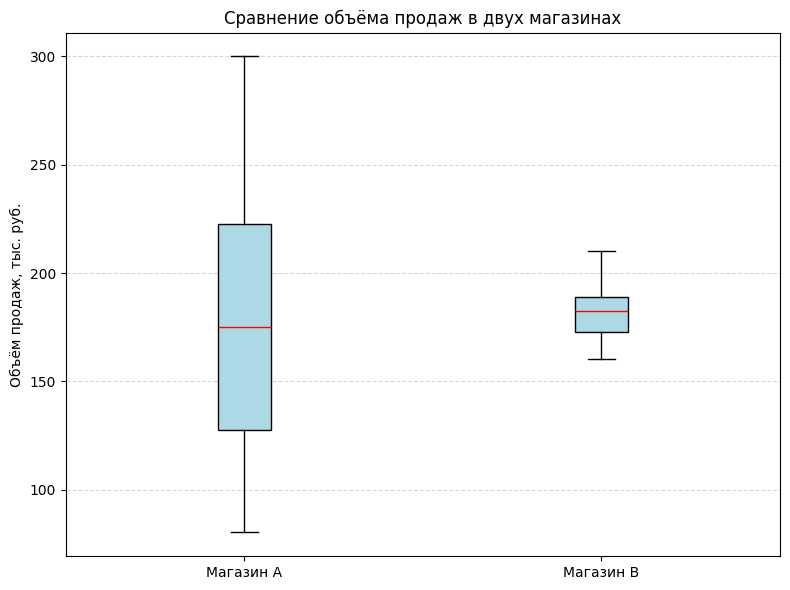

In [66]:
plt.figure(figsize=(8, 6))
plt.boxplot([shop_A, shop_B], labels=['Магазин A', 'Магазин B'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title("Сравнение объёма продаж в двух магазинах")
plt.ylabel("Объём продаж, тыс. руб.")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

На графике видны:

- медианы (красные линии),
- разброс,
- выбросы,
- насколько группы перекрываются.

Если групп больше двух — используем ANOVA:

In [69]:
from scipy.stats import f_oneway

# Добавим третий магазин
shop_C = [250.0, 240.5, 260.3, 230.1, 255.0]

f_stat, p_value_anova = f_oneway(shop_A, shop_B, shop_C)

print(f"F-статистика: {f_stat:.3f}")
print(f"p-value (ANOVA): {p_value_anova:.4f}")

if p_value_anova < alpha:
    print("→ Хотя бы одна группа отличается от других")
else:
    print("→ Нет значимых различий между группами")

F-статистика: 3.170
p-value (ANOVA): 0.0732
→ Нет значимых различий между группами


ANOVA говорит только о том, что хотя бы одна группа отличается, но не указывает, какая. Для этого нужны пост-хок тесты (например, Tukey’s HSD).

### Важные моменты при сравнении групп

| Фактор | Что проверить |
|-------|----------------|
| **Нормальность распределения** | Используйте график Q-Q или тест Шапиро-Уилка (`shapiro` из `scipy.stats`) |
| **Гомогенность дисперсий** | Проверьте с помощью теста Левена (`levene`) — важно для t-теста и ANOVA |
| **Размер выборки** | Маленькие выборки снижают мощность теста — эффект может быть упущен |
| **Практическая значимость** | Даже статистически значимое различие может быть слишком малым, чтобы быть полезным |
| **Независимость наблюдений** | Убедитесь, что данные из одной группы не зависят от другой |
| **Выбросы** | Могут сильно повлиять на среднее и дисперсию — используйте boxplot для диагностики |

# 2. Offline и online оценки 

## 2.1 Offline оценки

Offline-оценка (оффлайн-анализ) — это анализ гипотетического воздействия нового решения на уже имеющиеся данные, не проводя реальный A/B-тест.

**Примеры**:

- Вы обучили новый рекомендательный алгоритм. Можно ли оценить его метрики (CTR, конверсия) на данных старого трафика?
- Новый ранжирующий скор — как он бы себя показал на прошлых запросах?

Цель: отсеять плохие гипотезы и выбрать перспективные кандидаты для реального теста.

### Преимущества offline-оценки

| Преимущество | Пояснение |
|-------------|-----------|
| Быстрота и низкая стоимость | Оценка проводится на уже имеющихся данных — не нужно ждать сбора трафика |
| Безопасность для пользователей | Никакого влияния на пользовательский опыт или бизнес-показатели |
| Возможность быстрой итерации | Можно протестировать множество моделей или гипотез за короткое время |
| Контролируемая среда | Легче анализировать поведение модели без шумов продакшн-трафика |
| Поддержка сложных метрик | Можно оценивать NDCG, Precision@K, CTR и другие, не запуская эксперимент |

### Ограничения offline-оценки

| Ограничение | Пояснение |
|------------|-----------|
| Проблема выборочного смещения (selection bias) | Данные собраны под действием старой модели — новая может показывать другие элементы |
| Отсутствие обратной связи | Пользователи могли бы по-другому реагировать на новые действия системы |
| Нестационарность данных | Поведение пользователей со временем меняется — старые данные могут быть неактуальны |
| Не учитывает эффекты разнообразия, контекста, UX | Например, пользователь устанет от повторяющихся рекомендаций — это не видно в логах |
| Не заменяет онлайн-тесты | Offline-оценка — фильтр, но окончательное решение принимается только по результатам A/B-теста |

Offline-оценка — хороший фильтр, но не замена онлайн-тестам. 

### Методы offline-оценки

#### 1. Holdout-оценка (Train/Test Split)

Разделите данные на обучение и тест.
Оцените модель на тесте по стандартным метрикам:
- Accuracy, Precision, Recall (классификация)
- RMSE, MAE (регрессия)
- NDCG, MAP (ранжирование)

Подходит, если распределение данных стационарно.

#### 2. Cross-validation (кросс-валидация)

Разбиваем данные на K блоков, обучаем и оцениваем модель K раз.

Плюсы:
- Лучшая оценка устойчивости
- Уменьшает переобучение

Минус:
- Требует больше вычислений
- Не подходит при сильной временной зависимости

#### 3. Counterfactual Evaluation (оценка "что если бы?")

Самые продвинутые методы для оценки действий модели, которой ещё не было:

##### a) **Inverse Propensity Scoring (IPS)**  
Перевзвешивает события по вероятности их показа:
$$
\hat{R}_{IPS} = \frac{1}{n} \sum_{i=1}^n \frac{\mathbb{I}(a_i = \pi(x_i)) \cdot r_i}{p(a_i|x_i)}
$$
Где:
- $p(a_i|x_i)$ — вероятность показа элемента в исторических данных,
- $\pi(x_i)$ — действие новой модели,
- $r_i$ — вознаграждение (клики, покупки).

- Устраняет смещение отбора  
- Чувствителен к малым $p(a_i|x_i)$

##### b) **Doubly Robust (DR)**  
Комбинирует IPS и модель предсказания:
$$
\hat{R}_{DR} = \frac{1}{n} \sum_{i=1}^n \left[ \hat{r}(x_i, \pi(x_i)) + \frac{\mathbb{I}(a_i = \pi(x_i)) (r_i - \hat{r}(x_i, a_i))}{p(a_i|x_i)} \right]
$$

- Более стабилен, чем IPS  
- Работает даже при неточной модели

#### c) **Direct Method (DM)**  
Обучает модель предсказывать вознаграждение $\hat{r}(x,a)$, затем оценивает:
$$
\hat{R}_{DM} = \frac{1}{n} \sum_{i=1}^n \hat{r}(x_i, \pi(x_i))
$$

- Смещён, если модель предсказывает плохо  
- Прост в реализации

Пример: простая offline-оценка CTR

Допустим, у нас есть логи показов и кликов:

In [75]:
# Имитация логов: что показали, был ли клик, с какой вероятностью показали
logs = pd.DataFrame({
    'item': ['A', 'B', 'C', 'A', 'B'],
    'click': [1, 0, 1, 0, 1],
    'propensity': [0.8, 0.5, 0.6, 0.8, 0.5],  # p(a|x) — вероятность показа
    'score_new_model': [0.9, 0.7, 0.5, 0.8, 0.6]  # скор новой модели
})

# Предположим: новая модель выбрала бы item с max score
# Новая модель выбирает item с максимальным score_new_model
new_policy_action = logs.loc[logs['score_new_model'].idxmax(), 'item']  # item 'A'

# Фильтруем только те строки, где старая система показала то же, что выбрала бы новая
relevant_logs = logs[logs['item'] == new_policy_action]

# Теперь считаем IPS: только для тех случаев, где действие совпало
ips_estimate_correct = (relevant_logs['click'] / relevant_logs['propensity']).mean()

print(f"Новая модель выбрала: {new_policy_action}")
print(f"Релевантные показы: {len(relevant_logs)}")
print(f"Правильная оценка CTR (IPS): {ips_estimate_correct:.3f}")

Новая модель выбрала: A
Релевантные показы: 2
Правильная оценка CTR (IPS): 0.625


На основе offline-оценки с использованием метода Inverse Propensity Scoring (IPS), оценка CTR для новой модели составляет 0.625.

Это выше, чем текущий CTR по всем данным (0.6), но разница небольшая.

Важно отметить, что оценка основана только на тех случаях, когда новая модель выбрала тот же элемент, который ранее показывала старая система.

Поскольку количество таких наблюдений ограничено (2 из 5), оценка имеет высокую дисперсию и требует дополнительной проверки.

### Когда использовать offline-оценку?

| Ситуация | Рекомендуемый подход |
|--------|------------------------|
| **Первая оценка качества модели** | Holdout-выборка или кросс-валидация для базовой проверки |
| **Сравнение нескольких моделей** | Offline-метрики (NDCG, CTR, RMSE и др.) для ранжирования кандидатов |
| **Ранжирование или рекомендации** | IPS, Doubly Robust, Direct Method — для учёта смещения отбора |
| **Оценка новых признаков или алгоритмов** | Проверка на исторических данных перед запуском в A/B-тест |
| **Ограниченный трафик для A/B-тестов** | Используйте offline-оценку, чтобы отсеять заведомо слабые гипотезы |
| **Высокая стоимость ошибки в продакшне** | Протестируйте модель offline, прежде чем запускать на реальных пользователях |
| **Построение бейзлайнов** | Оцените простые правила (например, "топ по популярности") перед обучением ML-модели |

Offline-оценка — важный этап в цикле ML / A/B-тестирования:

- Позволяет быстро отсеять плохие идеи.
- Экономит трафик и ресурсы.
- Требует осторожности из-за смещений.

Идеальный путь:
Offline-оценка → Онлайн A/B-тест → Анализ результатов 

## 2.2 Onlinee оценки

**Online-оценка** — это оценка эффективности модели или изменения в реальных условиях, когда новое решение (например, модель, интерфейс, алгоритм) тестируется на реальных пользователях.

В отличие от offline-подходов, online-оценка учитывает:

- реальное поведение пользователей,
- обратную связь системы,
- контекст взаимодействия (устройство, время, локация и т.д.).

Цель: понять, улучшает ли изменение ключевые бизнес-метрики (конверсия, CTR, доход, удержание и др.).

**Когда используется online-оценка?**

- После успешной offline-оценки.
- Для принятия финального решения о запуске.
- При сравнении двух или более версий продукта (A/B, A/B/C-тесты).
- В системах с динамическим поведением: рекомендации, ранжирование, реклама.

**Основные метрики online-оценки**
| Тип метрики | Примеры |
|-------------|-----------|
| Поведенческие | CTR, время на странице, глубина просмотра |
|Бизнес-метрики | Конверсия, средний чек, ARPU, LTV | 
| Системные | Latency, ошибка предсказания, покрытие | 
| Юзабилити | NPS, количество ошибок, частота использования | 

**Преимущества online-оценки**

| Преимущество | Пояснение |
|-------------|-----------|
| Реалистичность | Данные собираются от реальных пользователей в реальном времени |
| Учёт обратной связи | Пользователи могут по-разному реагировать на изменения — это видно только онлайн |
| Оценка долгосрочных эффектов | Можно измерить влияние на удержание, повторные покупки и др. |
| Измерение истинного бизнес-эффекта | Не "как бы", а "что реально произошло" |
| Поддержка итераций | Быстрая проверка гипотез → улучшение продукта |

### Ограничения online-оценки

| Ограничение | Пояснение |
|------------|-----------|
| Длительность | Нужно собрать достаточно данных — может занять недели |
| Стоимость | Риск потерять деньги/пользователей, если тест плохой |
| Сложность реализации | Требуется корректное сплитование, учёт подмешивания, защита от bias |
| Влияние на UX | Плохое изменение может испортить опыт пользователей |
| Параллельные тесты (interference)** | Эффект одного теста может мешать другому (например, два UI-изменения) |
| Малые эффекты трудно обнаружить | Нужна высокая мощность теста (большой размер выборки) |

Offline-оценка — можно ли?

Online-оценка — работает ли на самом деле? 

- Offline помогает отсеять плохие идеи.
- Online — даёт окончательный ответ на вопрос: стоит ли запускать?

Идеальный путь:

Offline → Online A/B-тест → Анализ → Деплой (или доработка)

# 3. AB-тестирование

**A/B-тест (сплит-тест)** — это эксперимент, в котором две версии продукта (например, сайта, приложения, рекомендательной системы) сравниваются между собой, чтобы определить, какая из них лучше влияет на ключевую метрику (CTR, конверсия, доход и т.д.).

**Основные понятия:**
- Группа A (контроль) — текущая версия (baseline).
- Группа B (тест) — новая версия (например, новый дизайн, алгоритм).
- Метрика — количественный показатель для сравнения (например, конверсия).
- Статистическая значимость — проверка, не случайно ли различие.

Цель: принимать решения на основе данных, а не интуиции. 

**Пример: A/B-тест для кнопки "Купить"**

Представьте, что вы хотите проверить, увеличит ли красный цвет кнопки конверсию по сравнению с синим.

Данные:
- Группа A (синяя кнопка): 1000 посетителей, 120 купили → конверсия = 12%
- Группа B (красная кнопка): 1000 посетителей, 140 купили → конверсия = 14%

Хотим проверить: различие статистически значимо?

In [82]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# Данные
data = pd.DataFrame({
    'Группа': ['A', 'B'],
    'Посетители': [1000, 1000],
    'Покупки': [120, 140]
})

# Конверсия
data['Конверсия'] = data['Покупки'] / data['Посетители']

data

,Группа,Посетители,Покупки,Конверсия
0,A,1000,120,0.12
1,B,1000,140,0.14


Вариант 1: z-тест для долей (подходит при больших выборках)


In [84]:
# z-тест
z_stat, p_value = proportions_ztest(
    count=data['Покупки'],      # число успехов
    nobs=data['Посетители'],    # размер группы
    alternative='two-sided'     # двусторонняя гипотеза
)

print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("→ Различие статистически значимо: красная кнопка лучше")
else:
    print("→ Различие не значимо: нет оснований менять цвет")

z-статистика: -1.330
p-value: 0.1836
→ Различие не значимо: нет оснований менять цвет


Несмотря на рост конверсии с 12% до 14%, различие не является статистически значимым при уровне значимости α=0.05 (p-value = 0.1836 > 0.05).
Это означает, что наблюдаемое различие может быть вызвано случайной вариацией, а не реальным эффектом от изменения цвета кнопки.

Рекомендация:

Не стоит менять цвет кнопки на основании этого теста — нет достаточных доказательств эффективности изменения.
Для повышения мощности теста можно увеличить размер выборки или продолжить эксперимент. 

Вариант 2: χ²-тест (альтернатива)

In [87]:
# Таблица сопряжённости (2x2): Группа × Результат
contingency_table = pd.DataFrame({
    'Купил': [120, 140],          # A и B
    'Не купил': [1000 - 120, 1000 - 140]  # 880 и 860
}, index=['A', 'B'])

print("\nТаблица сопряжённости:")
print(contingency_table)

# χ²-тест
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nχ²-статистика: {chi2:.3f}, p-value: {p:.4f}")

if p < alpha:
    print("→ Различие статистически значимо (по χ²)")
else:
    print("→ Различие не значимо (по χ²)")


Таблица сопряжённости:
   Купил  Не купил
A    120       880
B    140       860

χ²-статистика: 1.596, p-value: 0.2065
→ Различие не значимо (по χ²)


Результат χ²-теста подтверждает вывод z-теста: p-value = 0.2065 > 0.05 → различие не статистически значимо.
Обе группы (A и B) демонстрируют схожее распределение по результатам "купил/не купил".

Значения p-value в z-тесте и χ²-тесте немного отличаются — это нормально, так как методы используют разные подходы к расчёту. Однако оба указывают на одно и то же: нет оснований отвергать нулевую гипотезу. 

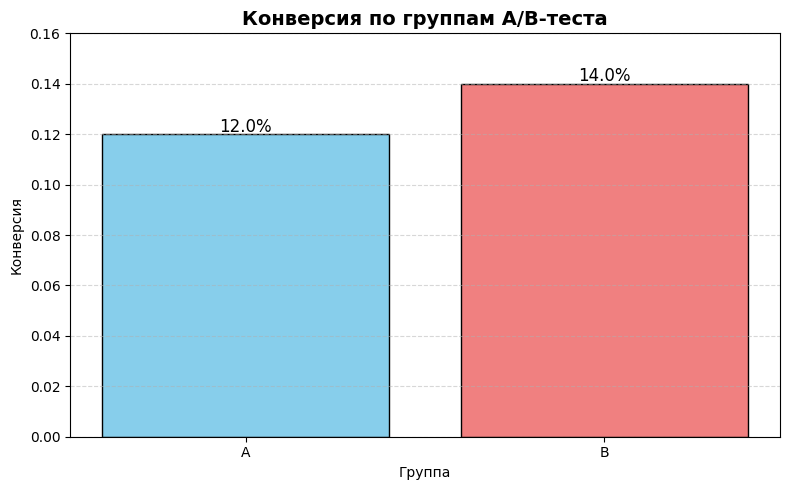

In [89]:
plt.figure(figsize=(8, 5))
bars = plt.bar(data['Группа'], data['Конверсия'], color=['skyblue', 'lightcoral'], edgecolor='black')

# Подписи сверху
for bar, conv in zip(bars, data['Конверсия']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{conv:.1%}', ha='center', fontsize=12)

plt.title('Конверсия по группам A/B-теста', fontsize=14, fontweight='bold')
plt.ylabel('Конверсия')
plt.xlabel('Группа')
plt.ylim(0, 0.16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [90]:
import statsmodels.api as sm

# Доверительные интервалы для долей
ci_a = sm.stats.proportion_confint(120, 1000, method='wilson')
ci_b = sm.stats.proportion_confint(140, 1000, method='wilson')

print(f"Группа A: {data['Конверсия'][0]:.1%} [{ci_a[0]:.1%}, {ci_a[1]:.1%}]")
print(f"Группа B: {data['Конверсия'][1]:.1%} [{ci_b[0]:.1%}, {ci_b[1]:.1%}]")

Группа A: 12.0% [10.1%, 14.2%]
Группа B: 14.0% [12.0%, 16.3%]


Интерпретация результатов A/B-теста:

- Группа B (красная кнопка) показала **более высокую конверсию (14.0%)**, чем группа A (синяя кнопка, 12.0%).
- Однако различие **не является статистически значимым** (p > 0.05), что означает: наблюдаемая разница может быть вызвана случайной вариацией, а не реальным эффектом изменения цвета.
- Доверительные интервалы для долей перекрываются:
  - Группа A: [10.1%, 14.2%]
  - Группа B: [12.0%, 16.3%]
  → Это подтверждает, что разница не достоверна.
  
**Рекомендации:**
- Не запускать изменение в продакшн на основании текущих данных.
- Продлить тест или увеличить трафик, чтобы повысить мощность теста и обнаружить малые эффекты.
- Рассмотреть другие гипотезы (например, текст на кнопке, её размер, расположение).

**Важно:** Статистическая незначимость ≠ отсутствие эффекта — это значит, что **данных недостаточно**, чтобы его доказать.